КЛАССИФИКАЦИЯ ТИПОВ АКУСТИЧЕСКИХ СИГНАЛОВ

Параметры:
  Частота дискретизации: 48000 Гц
  Длительность: 0.5 с
  SNR: 30 дБ

Генерация сигналов...
1. Гармонический сигнал (440 Гц)
  Распознан как: harmonic
  Концентрация спектра: 0.9990
  Пик-фактор: 1.51
  Энергия в полосе 100–500 Гц: 0.9990
2. Широкополосный сигнал (100–500 Гц)
  Распознан как: wideband
  Концентрация спектра: 0.0308
  Пик-фактор: 4.20
  Энергия в полосе 100–500 Гц: 0.9512
3. Импульсный сигнал
  Распознан как: impulse
  Концентрация спектра: 0.0141
  Пик-фактор: 16.82
  Энергия в полосе 100–500 Гц: 0.3762
СТАТИСТИЧЕСКАЯ ОЦЕНКА (1000 экспериментов)

Результаты классификации сигналов (голосование)
--------------------------------------------------------------------------------
Истинный тип         Гармонический        Широкополосный       Импульсный      Точность  
--------------------------------------------------------------------------------
harmonic             1000                 0                    0            

/tmp/ipykernel_3167/2539728707.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


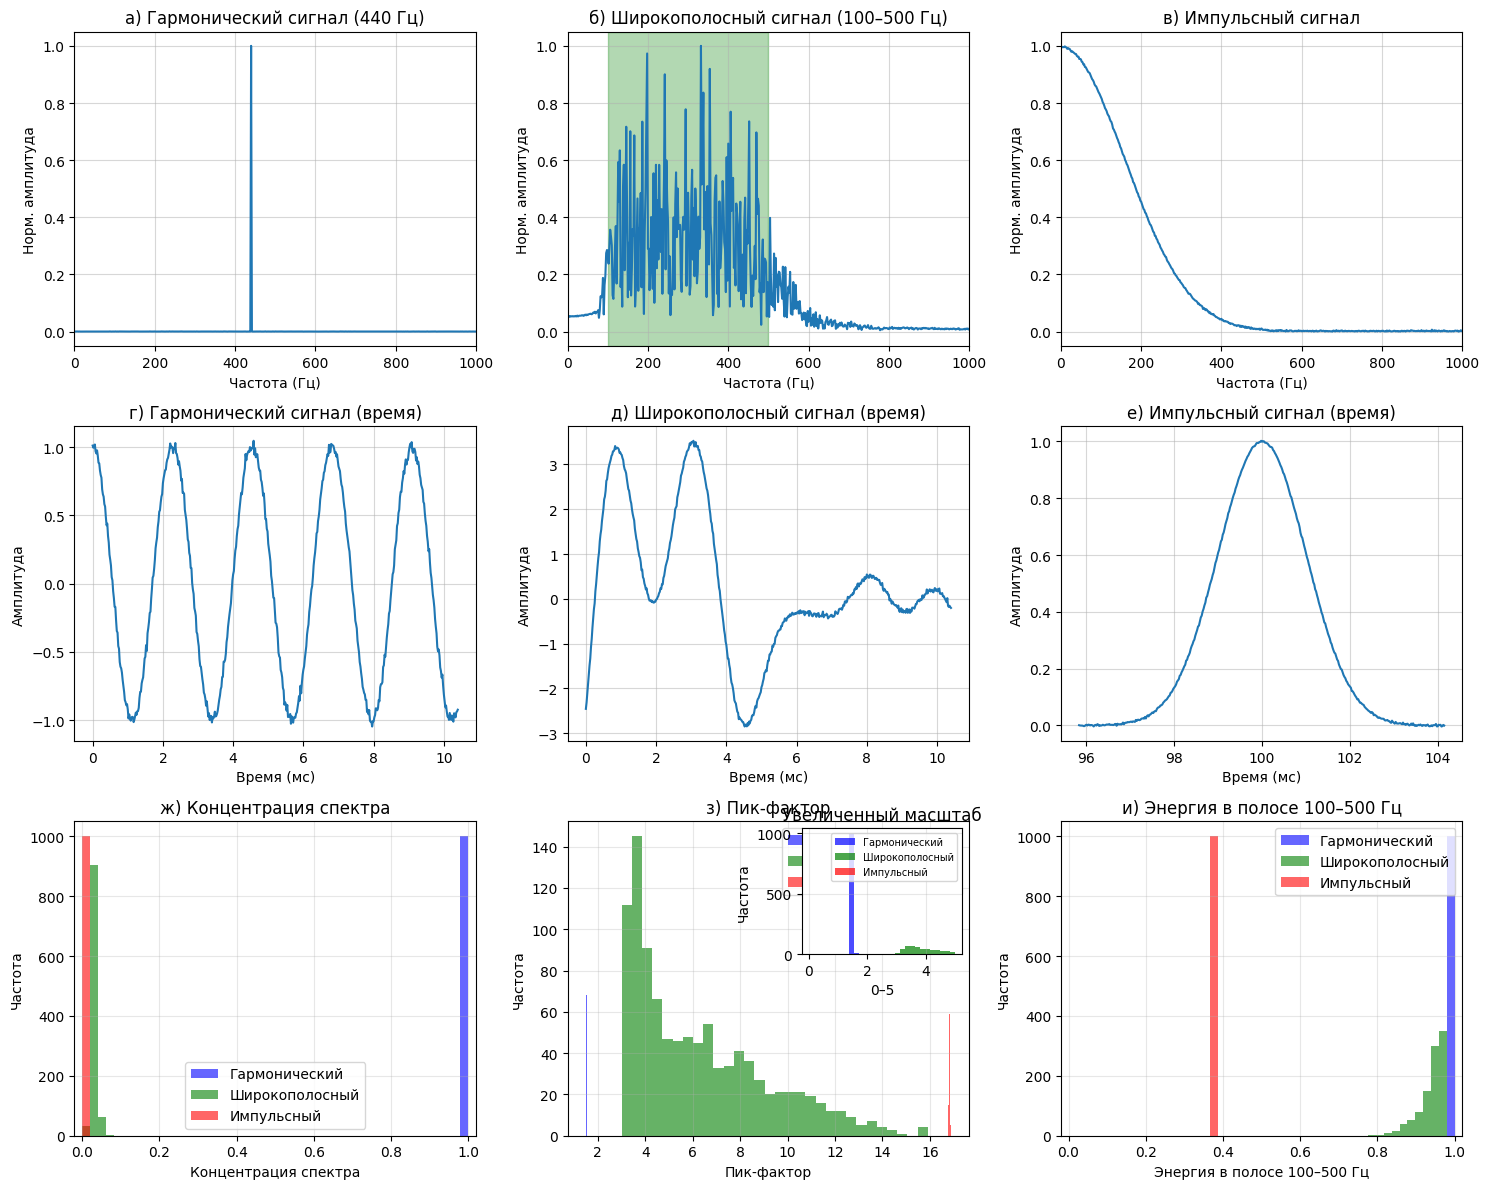

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1. Генерация сигналов различных типов

def generate_harmonic_signal(fs, T, f0, A=1.0):
    """Генерация гармонического сигнала"""
    t = np.arange(0, T, 1/fs)
    s = A * np.cos(2 * np.pi * f0 * t)
    return t, s

def generate_wideband_signal(fs, T, f_min, f_max, order=4):
    """Генерация широкополосного сигнала (фильтрованный белый шум)"""
    t = np.arange(0, T, 1/fs)
    white_noise = np.random.randn(len(t))
    nyquist = fs / 2
    b, a = butter(order, [f_min / nyquist, f_max / nyquist], btype='band')
    s = filtfilt(b, a, white_noise)
    s = np.nan_to_num(s, nan=0.0)
    rms = np.sqrt(np.mean(s**2))
    if rms > 1e-12:
        s = s / rms
    else:
        s = np.random.randn(len(t))
        s = s / np.sqrt(np.mean(s**2))
    return t, s

def generate_impulse_signal(fs, T, t0=0.1, sigma=0.001, A=1.0):
    """Генерация импульсного сигнала (гауссов импульс)"""
    t = np.arange(0, T, 1/fs)
    s = A * np.exp(-(t - t0)**2 / (2 * sigma**2))
    s = s / np.max(s)
    return t, s

def add_noise(signal, SNR_dB):
    """Добавление шума с заданным отношением сигнал/шум"""
    signal_power = np.mean(signal**2)
    if signal_power < 1e-12:
        signal_power = 1.0
    noise_power = signal_power / (10**(SNR_dB/10))
    noise = np.sqrt(noise_power) * np.random.randn(len(signal))
    return signal + noise

# 2. Вычисление признаков

def compute_spectral_features(signal, fs):
    """
    Вычисление спектральных признаков сигнала.

    Параметры:
        signal : ndarray — сигнал
        fs : float — частота дискретизации (Гц)

    Возвращает:
        features : dict — словарь с признаками
    """
    # БПФ
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), 1/fs)
    energy = fft_vals**2

    total_energy = np.sum(energy)
    max_energy = np.max(energy)
    concentration = max_energy / total_energy if total_energy > 0 else 0

    rms = np.sqrt(np.mean(signal**2))
    peak_factor = np.max(np.abs(signal)) / rms if rms > 0 else 0

    # энергия в полосе 100–500 Гц
    mask = (freqs >= 100) & (freqs <= 500)
    energy_band = np.sum(energy[mask])
    band_ratio = energy_band / total_energy if total_energy > 0 else 0

    return {
        'concentration': concentration,
        'peak_factor': peak_factor,
        'band_ratio': band_ratio
    }

# 3. Классификация

def classify_signal(signal, fs):

    features = compute_spectral_features(signal, fs)

    scores = {'harmonic': 0, 'wideband': 0, 'impulse': 0}

    # 1 признак: концентрация спектра
    if features['concentration'] > 0.5:
        scores['harmonic'] += 3
    elif features['concentration'] < 0.1:
        scores['wideband'] += 1
        scores['impulse'] += 1

    # 2 признак: энергия в полосе 100–500 Гц
    if features['band_ratio'] > 0.7:
        scores['wideband'] += 3
    elif features['band_ratio'] < 0.3:
        scores['impulse'] += 1

    # 3 признак: пик-фактор
    if features['peak_factor'] > 6.0:
        scores['impulse'] += 2
    elif features['peak_factor'] < 4.0:
        scores['wideband'] += 1
        scores['harmonic'] += 1

    signal_type = max(scores, key=scores.get)
    return signal_type, features

# 4. Основная функция

if __name__ == "__main__":
    np.random.seed(42)

    print("КЛАССИФИКАЦИЯ ТИПОВ АКУСТИЧЕСКИХ СИГНАЛОВ")

    # параметры
    fs = 48000
    T = 0.5
    SNR_dB = 30

    print(f"\nПараметры:")
    print(f"  Частота дискретизации: {fs} Гц")
    print(f"  Длительность: {T} с")
    print(f"  SNR: {SNR_dB} дБ")

    print("\nГенерация сигналов...")

    t, s_harm = generate_harmonic_signal(fs, T, f0=440)
    s_harm_noisy = add_noise(s_harm, SNR_dB)

    t, s_wide = generate_wideband_signal(fs, T, f_min=100, f_max=500)
    s_wide_noisy = add_noise(s_wide, SNR_dB)

    t, s_imp = generate_impulse_signal(fs, T, t0=0.1, sigma=0.001)
    s_imp_noisy = add_noise(s_imp, SNR_dB)

    print("1. Гармонический сигнал (440 Гц)")

    type_harm, features_harm = classify_signal(s_harm_noisy, fs)
    print(f"  Распознан как: {type_harm}")
    print(f"  Концентрация спектра: {features_harm['concentration']:.4f}")
    print(f"  Пик-фактор: {features_harm['peak_factor']:.2f}")
    print(f"  Энергия в полосе 100–500 Гц: {features_harm['band_ratio']:.4f}")

    print("2. Широкополосный сигнал (100–500 Гц)")

    type_wide, features_wide = classify_signal(s_wide_noisy, fs)
    print(f"  Распознан как: {type_wide}")
    print(f"  Концентрация спектра: {features_wide['concentration']:.4f}")
    print(f"  Пик-фактор: {features_wide['peak_factor']:.2f}")
    print(f"  Энергия в полосе 100–500 Гц: {features_wide['band_ratio']:.4f}")

    print("3. Импульсный сигнал")

    type_imp, features_imp = classify_signal(s_imp_noisy, fs)
    print(f"  Распознан как: {type_imp}")
    print(f"  Концентрация спектра: {features_imp['concentration']:.4f}")
    print(f"  Пик-фактор: {features_imp['peak_factor']:.2f}")
    print(f"  Энергия в полосе 100–500 Гц: {features_imp['band_ratio']:.4f}")

    # статистическая оценка

    print("СТАТИСТИЧЕСКАЯ ОЦЕНКА (1000 экспериментов)")


    n_tests = 1000
    results = {'harmonic': {'harmonic': 0, 'wideband': 0, 'impulse': 0},
               'wideband': {'harmonic': 0, 'wideband': 0, 'impulse': 0},
               'impulse': {'harmonic': 0, 'wideband': 0, 'impulse': 0}}

    all_features = {'harmonic': [], 'wideband': [], 'impulse': []}

    for _ in range(n_tests):
        # гармонический
        _, s_h = generate_harmonic_signal(fs, T, f0=440)
        s_h_noisy = add_noise(s_h, SNR_dB)
        type_h, feat_h = classify_signal(s_h_noisy, fs)
        results['harmonic'][type_h] += 1
        all_features['harmonic'].append(feat_h)

        # широкополосный
        _, s_w = generate_wideband_signal(fs, T, f_min=100, f_max=500)
        s_w_noisy = add_noise(s_w, SNR_dB)
        type_w, feat_w = classify_signal(s_w_noisy, fs)
        results['wideband'][type_w] += 1
        all_features['wideband'].append(feat_w)

        # импульсный
        _, s_i = generate_impulse_signal(fs, T, t0=0.1, sigma=0.001)
        s_i_noisy = add_noise(s_i, SNR_dB)
        type_i, feat_i = classify_signal(s_i_noisy, fs)
        results['impulse'][type_i] += 1
        all_features['impulse'].append(feat_i)

    print("\nРезультаты классификации сигналов (голосование)")
    print("-" * 80)
    print(f"{'Истинный тип':<20} {'Гармонический':<20} {'Широкополосный':<20} {'Импульсный':<15} {'Точность':<10}")
    print("-" * 80)

    for true_type in ['harmonic', 'wideband', 'impulse']:
        r = results[true_type]
        total = sum(r.values())
        accuracy = r[true_type] / total * 100
        print(f"{true_type:<20} {r['harmonic']:<20} {r['wideband']:<20} {r['impulse']:<15} {accuracy:.0f}%")

# Визуализация

print("\nПостроение графиков...")

colors = {'harmonic': 'blue', 'wideband': 'green', 'impulse': 'red'}
labels = {'harmonic': 'Гармонический', 'wideband': 'Широкополосный', 'impulse': 'Импульсный'}

fig = plt.figure(figsize=(15, 12))

# Рисунок а: спектр гармонического сигнала
ax1 = plt.subplot(3, 3, 1)
fft_harm = np.abs(np.fft.rfft(s_harm_noisy))
freqs = np.fft.rfftfreq(len(s_harm_noisy), 1/fs)
ax1.plot(freqs, fft_harm / np.max(fft_harm))
ax1.set_xlabel('Частота (Гц)')
ax1.set_ylabel('Норм. амплитуда')
ax1.set_title('а) Гармонический сигнал (440 Гц)')
ax1.grid(True, alpha=0.5)
ax1.set_xlim(0, 1000)

# Рисунок б: спектр широкополосного сигнала
ax2 = plt.subplot(3, 3, 2)
fft_wide = np.abs(np.fft.rfft(s_wide_noisy))
ax2.plot(freqs, fft_wide / np.max(fft_wide))
ax2.axvspan(100, 500, alpha=0.3, color='green')
ax2.set_xlabel('Частота (Гц)')
ax2.set_ylabel('Норм. амплитуда')
ax2.set_title('б) Широкополосный сигнал (100–500 Гц)')
ax2.grid(True, alpha=0.5)
ax2.set_xlim(0, 1000)

# Рисунок в: спектр импульсного сигнала
ax3 = plt.subplot(3, 3, 3)
fft_imp = np.abs(np.fft.rfft(s_imp_noisy))
ax3.plot(freqs, fft_imp / np.max(fft_imp))
ax3.set_xlabel('Частота (Гц)')
ax3.set_ylabel('Норм. амплитуда')
ax3.set_title('в) Импульсный сигнал')
ax3.grid(True, alpha=0.5)
ax3.set_xlim(0, 1000)

# Рисунок г: гармонический сигнал во времени
ax4 = plt.subplot(3, 3, 4)
ax4.plot(t[:500] * 1000, s_harm_noisy[:500])
ax4.set_xlabel('Время (мс)')
ax4.set_ylabel('Амплитуда')
ax4.set_title('г) Гармонический сигнал (время)')
ax4.grid(True, alpha=0.5)

# Рисунок д: широкополосный сигнал во времени
ax5 = plt.subplot(3, 3, 5)
ax5.plot(t[:500] * 1000, s_wide_noisy[:500])
ax5.set_xlabel('Время (мс)')
ax5.set_ylabel('Амплитуда')
ax5.set_title('д) Широкополосный сигнал (время)')
ax5.grid(True, alpha=0.5)

# Рисунок е: импульсный сигнал во времени
ax6 = plt.subplot(3, 3, 6)
t0_samples = int(0.1 * fs)
n_before = 200
n_after = 200
start = t0_samples - n_before
end = t0_samples + n_after
ax6.plot(t[start:end] * 1000, s_imp_noisy[start:end])
ax6.set_xlabel('Время (мс)')
ax6.set_ylabel('Амплитуда')
ax6.set_title('е) Импульсный сигнал (время)')
ax6.grid(True, alpha=0.5)

# Рисунок ж: концентрация спектра (улучшенное разрешение)
ax7 = plt.subplot(3, 3, 7)
for signal_type in ['harmonic', 'wideband', 'impulse']:
    values = [f['concentration'] for f in all_features[signal_type]]
    ax7.hist(values, bins=np.linspace(0, 1, 50), alpha=0.6,
             color=colors[signal_type], label=labels[signal_type])
ax7.set_xlabel('Концентрация спектра')
ax7.set_ylabel('Частота')
ax7.set_title('ж) Концентрация спектра')
ax7.legend()
ax7.grid(True, alpha=0.3)
ax7.set_xlim(-0.02, 1.02)

# Рисунок з: пик-фактор
ax8 = plt.subplot(3, 3, 8)
for signal_type in ['harmonic', 'wideband', 'impulse']:
    values = [f['peak_factor'] for f in all_features[signal_type]]
    ax8.hist(values, bins=30, alpha=0.6, color=colors[signal_type], label=labels[signal_type])
ax8.set_xlabel('Пик-фактор')
ax8.set_ylabel('Частота')
ax8.set_title('з) Пик-фактор')
ax8.legend()
ax8.grid(True, alpha=0.3)

inset_peak = inset_axes(ax8, width="40%", height="40%", loc='upper right')
for signal_type in ['harmonic', 'wideband', 'impulse']:
    values = [f['peak_factor'] for f in all_features[signal_type]]
    inset_peak.hist(values, bins=np.linspace(0, 5, 30), alpha=0.7,
                    color=colors[signal_type], label=labels[signal_type])
inset_peak.set_xlabel('0–5')
inset_peak.set_ylabel('Частота')
inset_peak.set_title('Увеличенный масштаб')
inset_peak.grid(True, alpha=0.3)
inset_peak.legend(fontsize=7)

# Рисунок и: энергия в полосе
ax9 = plt.subplot(3, 3, 9)
for signal_type in ['harmonic', 'wideband', 'impulse']:
    values = [f['band_ratio'] for f in all_features[signal_type]]
    ax9.hist(values, bins=np.linspace(0, 1, 50), alpha=0.6,
             color=colors[signal_type], label=labels[signal_type])
ax9.set_xlabel('Энергия в полосе 100–500 Гц')
ax9.set_ylabel('Частота')
ax9.set_title('и) Энергия в полосе 100–500 Гц')
ax9.legend()
ax9.grid(True, alpha=0.3)
ax9.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('signal_classification_all.png', dpi=300, bbox_inches='tight')
plt.show()